In [3]:
# fit a simple mlp model on the haberman and review learning curves
from pandas import read_csv
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from matplotlib import pyplot

# # define the location of the dataset
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/haberman.csv'
# # load the dataset
df = read_csv(url, header=None)
# # summarize shape
print(df.shape)

(306, 4)


                0           1           2           3
count  306.000000  306.000000  306.000000  306.000000
mean    52.457516   62.852941    4.026144    1.264706
std     10.803452    3.249405    7.189654    0.441899
min     30.000000   58.000000    0.000000    1.000000
25%     44.000000   60.000000    0.000000    1.000000
50%     52.000000   63.000000    1.000000    1.000000
75%     60.750000   65.750000    4.000000    2.000000
max     83.000000   69.000000   52.000000    2.000000


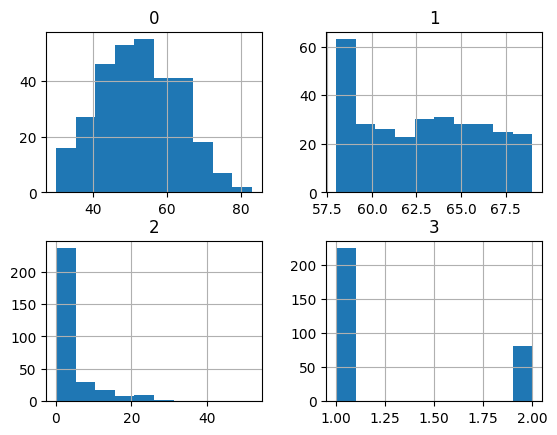

In [4]:
from pandas import read_csv
from matplotlib import pyplot
# define the location of the dataset
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/haberman.csv'
# load the dataset
df = read_csv(url, header=None)
# show summary statistics
print(df.describe())
# plot histograms
df.hist()
pyplot.show()

In [5]:
from pandas import read_csv
from collections import Counter
# define the location of the dataset
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/haberman.csv'
# define the dataset column names
columns = ['age', 'year', 'nodes', 'class']
# load the csv file as a data frame
dataframe = read_csv(url, header=None, names=columns)
# summarize the class distribution
target = dataframe['class'].values
counter = Counter(target)
for k,v in counter.items():
	per = v / len(target) * 100
	print('Class=%d, Count=%d, Percentage=%.3f%%' % (k, v, per))

Class=1, Count=225, Percentage=73.529%
Class=2, Count=81, Percentage=26.471%


# Neural Network Learning Dynamics

In [7]:
# split into input and output columns
X, y = df.values[:, :-1], df.values[:, -1]

# ensure all data are floating point values
X = X.astype('float32')
# encode strings to integer
y = LabelEncoder().fit_transform(y)

In [8]:
# split into train and test datasets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, stratify=y, random_state=3)

In [9]:
# determine the number of input features
n_features = X.shape[1]
# define model
model = Sequential()
model.add(Dense(10, activation='relu', kernel_initializer='he_normal', input_shape=(n_features,)))
model.add(Dense(1, activation='sigmoid'))
# compile the model
model.compile(optimizer='adam', loss='binary_crossentropy')

/Users/Licas/Desktop/workshop_Ilyas/cancerwkshop/lib/python3.13/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:

# fit the model
history = model.fit(X_train, y_train, epochs=200, batch_size=16, verbose=0, validation_data=(X_test,y_test))

In [12]:
# predict test set
yhat = (model.predict(X_test) > 0.5).astype("int32")
# evaluate predictions
score = accuracy_score(y_test, yhat)
print('Accuracy: %.3f' % score)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Accuracy: 0.745


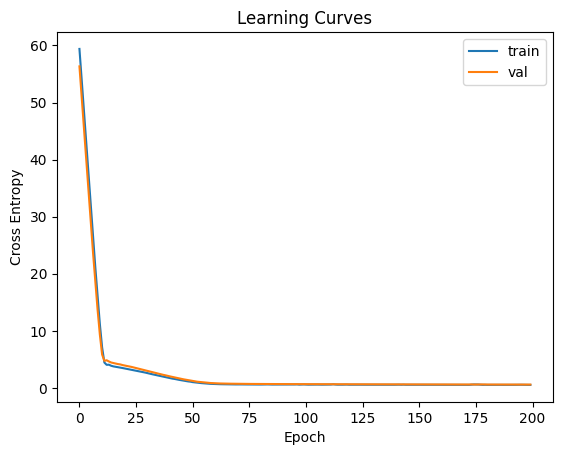

In [13]:

# plot learning curves
pyplot.title('Learning Curves')
pyplot.xlabel('Epoch')
pyplot.ylabel('Cross Entropy')
pyplot.plot(history.history['loss'], label='train')
pyplot.plot(history.history['val_loss'], label='val')
pyplot.legend()
pyplot.show()

/Users/Licas/Desktop/workshop_Ilyas/cancerwkshop/lib/python3.13/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Accuracy: 0.752


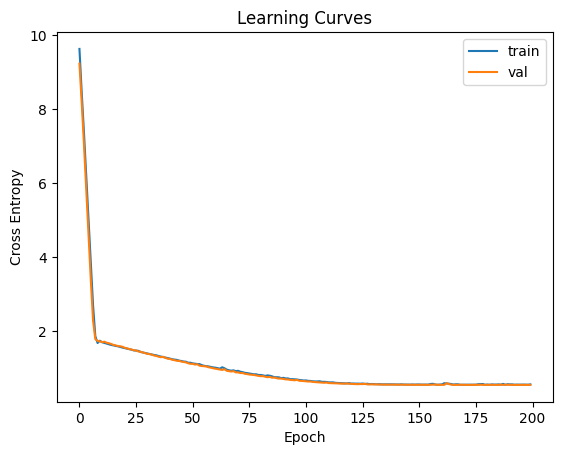

In [18]:
# fit a simple mlp model on the haberman and review learning curves
from pandas import read_csv
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from matplotlib import pyplot
# load the dataset
path = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/haberman.csv'
df = read_csv(path, header=None)
# split into input and output columns
X, y = df.values[:, :-1], df.values[:, -1]
# ensure all data are floating point values
X = X.astype('float32')
# encode strings to integer
y = LabelEncoder().fit_transform(y)
# split into train and test datasets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, stratify=y, random_state=3)
# determine the number of input features
n_features = X.shape[1]
# define model
model = Sequential()
model.add(Dense(10, activation='relu', kernel_initializer='he_normal', input_shape=(n_features,)))
model.add(Dense(1, activation='sigmoid'))
# compile the model
model.compile(optimizer='adam', loss='binary_crossentropy')
# fit the model
history = model.fit(X_train, y_train, epochs=200, batch_size=16, verbose=0, validation_data=(X_test,y_test))
# predict test set
yhat = (model.predict(X_test) > 0.5).astype("int32")
# evaluate predictions
score = accuracy_score(y_test, yhat)
print('Accuracy: %.3f' % score)
# plot learning curves
pyplot.title('Learning Curves')
pyplot.xlabel('Epoch')
pyplot.ylabel('Cross Entropy')
pyplot.plot(history.history['loss'], label='train')
pyplot.plot(history.history['val_loss'], label='val')
pyplot.legend()
pyplot.show()

# Robust Model Evaluation

In [19]:
import numpy as np
from pandas import read_csv
from sklearn.model_selection import KFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from numpy import mean, std

# 1. Chargement et préparation des données
path = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/haberman.csv'
df = read_csv(path, header=None)
X, y = df.values[:, :-1], df.values[:, -1]
X = X.astype('float32')
y = LabelEncoder().fit_transform(y)

# 2. Configuration de la Cross-Validation (10 plis)
kfold = KFold(10, shuffle=True, random_state=1)
scores = list()

print("Début de l'entraînement par K-Fold...")

# 3. Boucle d'énumération des splits
for train_ix, test_ix in kfold.split(X, y):
    # Sélection des données pour ce pli (fold)
    X_train, X_test = X[train_ix], X[test_ix]
    y_train, y_test = y[train_ix], y[test_ix]
    
    # Définition du modèle (on le recrée à chaque fois pour repartir de zéro)
    n_features = X.shape[1]
    model = Sequential()
    model.add(Dense(10, activation='relu', kernel_initializer='he_normal', input_shape=(n_features,)))
    model.add(Dense(1, activation='sigmoid'))
    
    # Compilation
    model.compile(optimizer='adam', loss='binary_crossentropy')
    
    # Entraînement (verbose=0 pour ne pas polluer la console)
    model.fit(X_train, y_train, epochs=200, batch_size=16, verbose=0)
    
    # Prédiction et calcul du score
    # Rappel : on ajoute > 0.5 pour transformer la probabilité en classe 0 ou 1
    yhat = (model.predict(X_test) > 0.5).astype("int32")
    
    # Calcul de l'accuracy pour ce pli
    acc = accuracy_score(y_test, yhat)
    scores.append(acc)
    print(f'> Pli terminé, accuracy: {acc:.3f}')

# 4. Résumé des performances
print('---')
print('Mean Accuracy: %.3f (%.3f)' % (mean(scores), std(scores)))

Début de l'entraînement par K-Fold...


/Users/Licas/Desktop/workshop_Ilyas/cancerwkshop/lib/python3.13/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
> Pli terminé, accuracy: 0.806


/Users/Licas/Desktop/workshop_Ilyas/cancerwkshop/lib/python3.13/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
> Pli terminé, accuracy: 0.742


...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
> Pli terminé, accuracy: 0.800


/Users/Licas/Desktop/workshop_Ilyas/cancerwkshop/lib/python3.13/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
> Pli terminé, accuracy: 0.867


/Users/Licas/Desktop/workshop_Ilyas/cancerwkshop/lib/python3.13/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
> Pli terminé, accuracy: 0.767
---
Mean Accuracy: 0.745 (0.071)


# Final Model and Make Predictions

In [21]:
import numpy as np
from pandas import read_csv
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

# load the dataset
path = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/haberman.csv'
df = read_csv(path, header=None)

# split into input and output columns
X, y = df.values[:, :-1], df.values[:, -1]
X = X.astype('float32')

# encode strings to integer (1 devient 0, 2 devient 1)
le = LabelEncoder()
y = le.fit_transform(y)

# define model
n_features = X.shape[1]
model = Sequential()
model.add(Dense(10, activation='relu', kernel_initializer='he_normal', input_shape=(n_features,)))
model.add(Dense(1, activation='sigmoid'))

# compile and fit
model.compile(optimizer='adam', loss='binary_crossentropy')
model.fit(X, y, epochs=200, batch_size=16, verbose=0)

# --- LA PARTIE QUI CHANGE ---

# 1. Définir la nouvelle ligne (il faut souvent l'envoyer comme un tableau 2D)
row = np.array([[30, 64, 1]]).astype('float32')

# 2. Remplacer predict_classes par predict + seuil
# predict() renvoie une probabilité, on la transforme en 0 ou 1
yhat_probs = model.predict(row)
yhat_class = (yhat_probs > 0.5).astype("int32")

# 3. Inverser la transformation (yhat_class doit être un tableau 1D pour inverse_transform)
yhat_label = le.inverse_transform(yhat_class.flatten())

# report prediction
print('Predicted Label: %s (Class: %d)' % (yhat_label[0], yhat_class.flatten()[0]))



/Users/Licas/Desktop/workshop_Ilyas/cancerwkshop/lib/python3.13/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Predicted Label: 1 (Class: 0)
